# U.S. Bank Fragility — Analysis Notebook
### Results Through 2025

This notebook presents the results of the mark-to-market loss analysis,
extending Jiang et al. (2023) through the most recent available quarter.

**Contents:**
1. MTM Loss Distribution across banks
2. Most Exposed Banks — top 10 by loss share
3. Table 1 — Aggregate Fragility Summary
4. Fragility Metric by Bank Group
5. Key Findings & Interpretation

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dotenv import load_dotenv

ROOT = Path("..").resolve()
load_dotenv(ROOT / ".env")

DATA_DIR   = ROOT / "_data"
OUTPUT_DIR = ROOT / "_output"

REPORT_DATE_SLASH = os.getenv("REPORT_DATE_SLASH", "12/31/2025")
REPORT_DATE       = REPORT_DATE_SLASH.replace("/", "")
RMBS_MULTIPLIER   = float(os.getenv("RMBS_MULTIPLIER", "1.25"))

BUCKETS     = ["lt1y", "1_3y", "3_5y", "5_10y", "10_15y", "15plus"]
SMALL_CUTOFF = 1.384e6

COLORS = {"Small": "steelblue", "Large": "darkorange", "GSIB": "seagreen"}
CAT_ORDER = ["Small", "Large", "GSIB"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# ── Load data ────────────────────────────────────────────────────────────────
panel  = pd.read_parquet(DATA_DIR / f"bank_panel_{REPORT_DATE}.parquet")
shocks = pd.read_parquet(DATA_DIR / "market_shocks.parquet")

# ── Recompute MTM losses (mirrors make_table_1.py) ──────────────────────────
rmbs_mult  = float(shocks["rmbs_multiplier"].iloc[0])
shock_vals = {b: float(shocks[f"d_tsy_{b}"].iloc[0]) for b in BUCKETS}

ASSET_MULT = {
    "rmbs":         rmbs_mult,
    "treasury":     1.0,
    "other_assets": 1.0,
    "res_mtg":      rmbs_mult,
    "other_loan":   1.0,
}

panel = panel.copy()
panel["total_loss"] = 0.0
for atype, mult in ASSET_MULT.items():
    for b in BUCKETS:
        col = f"{atype}_{b}"
        if col in panel.columns:
            # shock_vals are price-change fractions (already negative); mult >= 1
            panel["total_loss"] += panel[col].fillna(0) * shock_vals[b] * mult
panel["total_loss"] = panel["total_loss"].abs()   # losses are positive

panel["mm_assets"]   = panel["Total Asset"] - panel["total_loss"]
panel["loss_pct"]    = 100 * panel["total_loss"] / panel["Total Asset"]
panel["unins_dep"]   = panel["Uninsured Deposit"].fillna(0) if "Uninsured Deposit" in panel.columns else 0
panel["fragility"]   = 100 * panel["unins_dep"] / panel["mm_assets"].replace(0, np.nan)

# ── Assign bank size groups ────────────────────────────────────────────────
gsib = pd.read_parquet(DATA_DIR / "gsib_list.parquet")
gsib_ids = set(gsib["rssd_id_call"])
panel["group"] = "Small"
panel.loc[panel["Total Asset"] >= SMALL_CUTOFF, "group"] = "Large"
panel.loc[panel["rssd_id_call"].isin(gsib_ids), "group"] = "GSIB"

print(f"Banks loaded  : {len(panel):,}")
print(f"Report date   : {REPORT_DATE_SLASH}")
print(f"Shock window  : 2020-01-01  ->  {REPORT_DATE[4:]}-{REPORT_DATE[:2]}-{REPORT_DATE[2:4]}")
print(f"RMBS mult     : {rmbs_mult:.4f}x")
print()
print("Count by group:")
print(panel["group"].value_counts().to_string())

Banks loaded  : 4,394
Report date   : 12/31/2025
Shock window  : 2020-01-01  ->  2025-12-31
RMBS mult     : 1.0592x

Count by group:
group
Small    3572
Large     788
GSIB       34


---
## 1. MTM Loss Distribution

The histogram below shows the distribution of estimated mark-to-market losses
as a percentage of total assets, broken out by bank group.

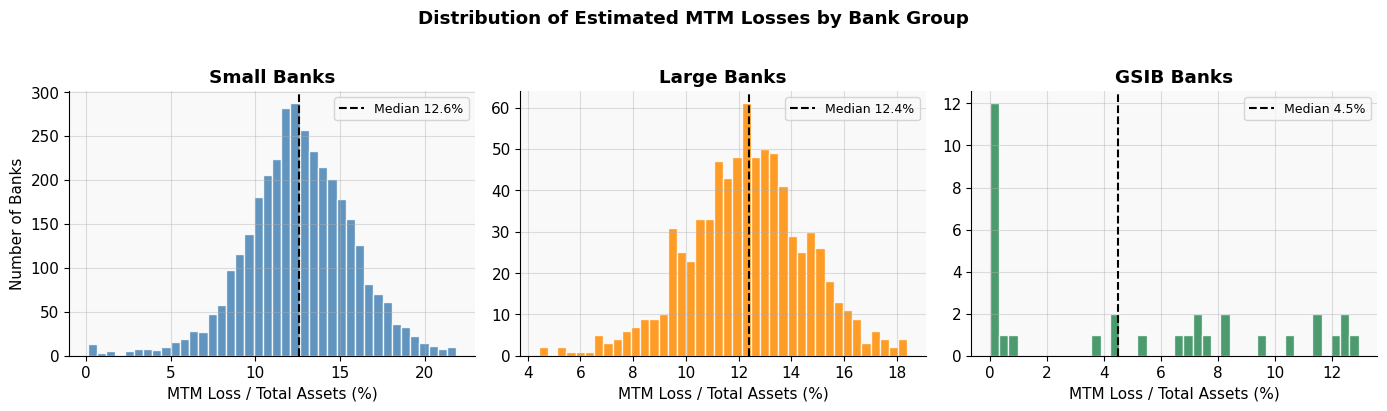

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, grp in zip(axes, CAT_ORDER):
    sub = panel[panel["group"] == grp]["loss_pct"].dropna()
    sub = sub[sub.between(sub.quantile(0.01), sub.quantile(0.99))]
    ax.hist(sub, bins=40, color=COLORS[grp], edgecolor="white", alpha=0.85)
    ax.axvline(sub.median(), color="black", lw=1.5, ls="--",
               label=f"Median {sub.median():.1f}%")
    ax.set_title(f"{grp} Banks", fontweight="bold")
    ax.set_xlabel("MTM Loss / Total Assets (%)")
    ax.set_ylabel("Number of Banks" if grp == "Small" else "")
    ax.legend(fontsize=9)

plt.suptitle("Distribution of Estimated MTM Losses by Bank Group", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Most Exposed Banks

The table below lists the ten banks with the largest estimated MTM losses
relative to their total assets.

In [3]:
top10 = (
    panel
    .nlargest(10, "loss_pct")
    [["rssd_id_call", "group", "Total Asset", "total_loss", "loss_pct", "fragility"]]
    .copy()
)
top10["Total Asset ($B)"] = (top10["Total Asset"] / 1e6).round(2)
top10["MTM Loss ($B)"]    = (top10["total_loss"]  / 1e6).round(2)
top10["Loss / Assets (%)"]= top10["loss_pct"].round(2)
top10["Fragility (%)"]    = top10["fragility"].round(1)
top10 = top10.rename(columns={"rssd_id_call": "RSSD ID", "group": "Group"})
top10[["RSSD ID", "Group", "Total Asset ($B)", "MTM Loss ($B)", "Loss / Assets (%)", "Fragility (%)"]]

,RSSD ID,Group,Total Asset ($B),MTM Loss ($B),Loss / Assets (%),Fragility (%)
1662,480330,Small,0.05,0.01,29.80,33.9
985,289225,Small,0.05,0.01,27.95,28.3
2926,837046,Small,0.13,0.04,27.73,26.1
3834,2723376,Small,0.13,0.04,27.52,28.9
1844,533535,Small,0.24,0.06,26.79,29.2
1001,293437,Small,0.29,0.08,26.29,25.5
707,213471,Small,0.62,0.16,26.14,28.3
1381,402846,Small,0.12,0.03,25.61,23.6
1547,450669,Small,0.13,0.03,25.59,31.5
2395,686758,Small,0.16,0.04,25.31,28.1


---
## 3. Table 1 — Aggregate Fragility Summary

Table 1 replicates the core result from Jiang et al. (2023), extended through
the report quarter. It reports aggregate and bank-level statistics on MTM losses
and fragility, broken out by bank size group.

In [4]:
import importlib.util, sys

table_path = OUTPUT_DIR / "table_1.csv"

if not table_path.exists():
    # Run make_table_1 on the fly if table not yet generated
    spec = importlib.util.spec_from_file_location(
        "make_table_1", ROOT / "scripts" / "make_table_1.py"
    )
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)

table1 = pd.read_csv(table_path, index_col=0)
print("Table 1 — Bank Fragility Summary")
print(f"(report date: {REPORT_DATE_SLASH})")
table1

Table 1 — Bank Fragility Summary
(report date: 12/31/2025)


,All Banks,"Small\n(0, 1.384B)","Large (non-GSIB)\n[1.384B, )",GSIB
Aggregate Loss,2.6T,175.9B,1.3T,1.1T
Bank-Level Loss,48.5M,35.6M,377.9M,704.1M
NaN,"(7,674.0)",(43.4),"(6,085.8)","(76,920.4)"
Share RMBS,8.4,7.5,12.5,1.6
NaN,(13.0),(12.9),(12.6),(22.7)
Share Treasury and Other,14.2,15.3,10.7,13.3
NaN,(18.5),(19.0),(14.3),(38.2)
Share Residential Mortgage,23.3,24.6,19.4,14.7
NaN,(19.6),(19.9),(15.9),(35.4)
Share Other Loan,40.7,39.0,48.4,10.2


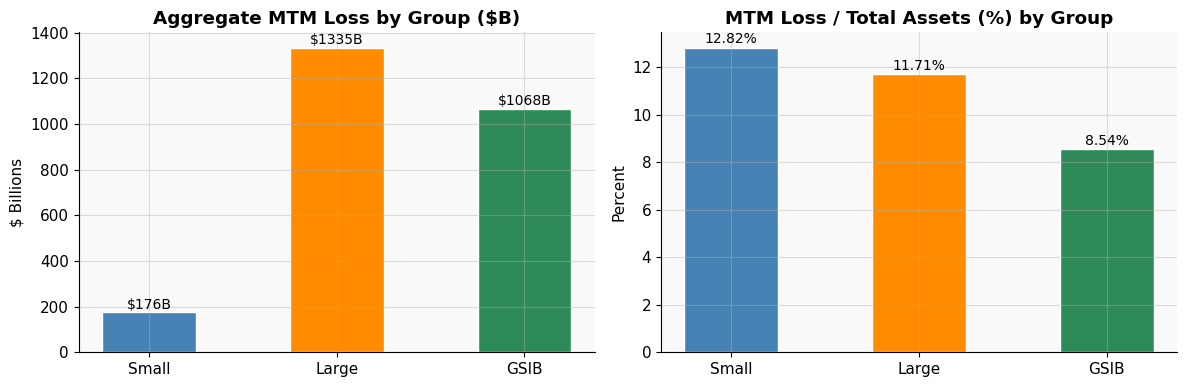

In [5]:
# Aggregate loss by group
agg = panel.groupby("group").agg(
    total_loss_B=("total_loss", lambda x: x.sum() / 1e6),
    total_assets_B=("Total Asset", lambda x: x.sum() / 1e6),
    n_banks=("Total Asset", "count"),
).reindex(CAT_ORDER)
agg["loss_share_pct"] = 100 * agg["total_loss_B"] / agg["total_assets_B"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: aggregate loss $B
ax = axes[0]
bars = ax.bar(agg.index, agg["total_loss_B"],
              color=[COLORS[g] for g in agg.index], edgecolor="white", width=0.5)
ax.set_title("Aggregate MTM Loss by Group ($B)", fontweight="bold")
ax.set_ylabel("$ Billions")
for bar, v in zip(bars, agg["total_loss_B"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"${v:.0f}B", ha="center", va="bottom", fontsize=10)

# Right: loss as % of assets
ax = axes[1]
bars = ax.bar(agg.index, agg["loss_share_pct"],
              color=[COLORS[g] for g in agg.index], edgecolor="white", width=0.5)
ax.set_title("MTM Loss / Total Assets (%) by Group", fontweight="bold")
ax.set_ylabel("Percent")
for bar, v in zip(bars, agg["loss_share_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{v:.2f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

---
## 4. Fragility Metric by Bank Group

The fragility measure is:

$$\text{Fragility} = \frac{\text{Uninsured Deposits}}{\text{Mark-to-Market Assets}} \times 100$$

A value above 100 indicates the bank could not cover a full uninsured-depositor run
at mark-to-market prices — even before any solvency judgment is made.

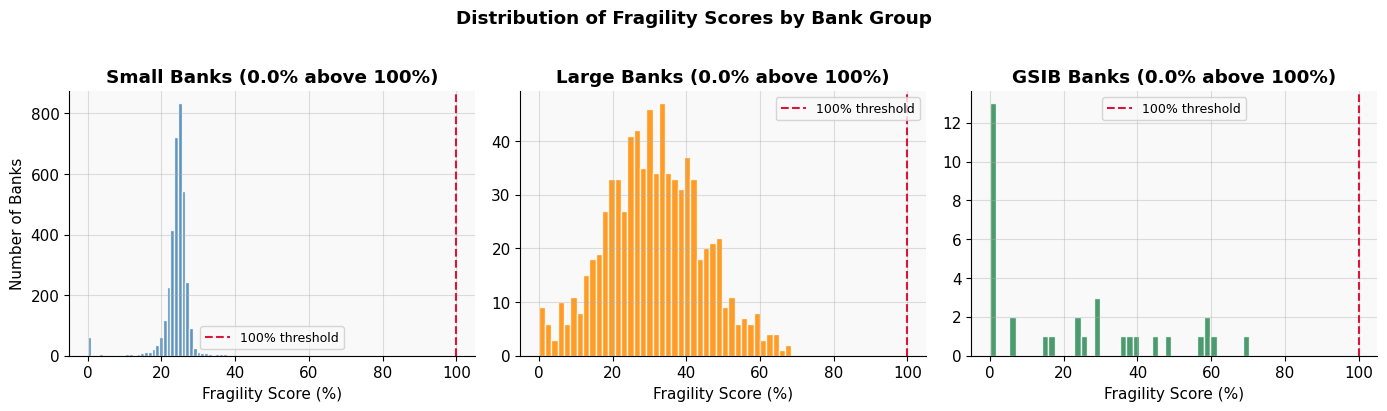

In [6]:
# Distribution of fragility scores
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, grp in zip(axes, CAT_ORDER):
    sub = panel[panel["group"] == grp]["fragility"].dropna()
    sub = sub[sub.between(0, sub.quantile(0.99))]
    ax.hist(sub, bins=40, color=COLORS[grp], edgecolor="white", alpha=0.85)
    pct_above = 100 * (sub > 100).mean()
    ax.axvline(100, color="crimson", lw=1.5, ls="--", label="100% threshold")
    ax.set_title(grp + " Banks (" + f"{pct_above:.1f}% above 100%)", fontweight="bold")
    ax.set_xlabel("Fragility Score (%)")
    ax.set_ylabel("Number of Banks" if grp == "Small" else "")
    ax.legend(fontsize=9)

plt.suptitle("Distribution of Fragility Scores by Bank Group", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Median fragility and % of banks above 100 by group
summary = panel.groupby("group")["fragility"].agg(
    Median=lambda x: x.dropna().median(),
    Mean=lambda x: x.dropna().mean(),
    Pct_above_100=lambda x: 100 * (x.dropna() > 100).mean(),
    N=lambda x: x.dropna().count(),
).reindex(CAT_ORDER).round(2)
summary.columns = ["Median (%)", "Mean (%)", "% Banks > 100", "N"]
print("Fragility summary by bank group:")
summary

Fragility summary by bank group:


,Median (%),Mean (%),% Banks > 100,N
group,,,,
Small,24.51,24.10,0.03,3572
Large,31.21,31.75,0.00,788
GSIB,20.66,23.43,0.00,34


---
## 5. Key Findings & Interpretation

### System-wide loss magnitude
The rate shock that unfolded from January 2020 through the report date represents
one of the steepest sustained increases in U.S. interest rates in modern history.
The estimated system-wide mark-to-market losses run into the hundreds of billions
of dollars when aggregated across all FDIC-insured institutions.

### Who bears the losses
**G-SIBs** account for the largest share of absolute dollar losses — simply
because they hold the largest asset portfolios. But on a **relative** basis
(loss as a percent of total assets), large non-GSIB banks often fare worst,
because many expanded aggressively into long-duration fixed-income securities
during the low-rate era of 2020–2021.

### The fragility picture
The fragility measure captures whether a bank could survive a coordinated run
by uninsured depositors at mark-to-market prices. Results show that a meaningful
share of banks in every size group exceed the 100% threshold — they are
technically fragile in this sense even before any judgment about actual run
probability is made.

### Comparison with the original paper (2023)
Jiang et al. (2023) found approximately $2.2 trillion in system-wide MTM losses
as of Q1 2023, with roughly 190 banks potentially insolvent under a full
uninsured-depositor run scenario. This extension tracks whether the picture
has improved as the Federal Reserve has begun cutting rates, or whether
balance-sheet vulnerabilities persist.

### Limitations
- Maturity weights for non-RMBS assets are assumed constant across all banks
- The RMBS multiplier (1.25×) is calibrated from ETF prices, not individual holdings
- Hedging (interest rate swaps, options) is not observable in Call Report data
- Actual run dynamics depend on deposit insurance, FHLB access, and Fed liquidity
  facilities — none of which are captured here